In [1]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, TensorDataset

%matplotlib inline
from matplotlib_inline import backend_inline
import matplotlib.pyplot as plt
backend_inline.set_matplotlib_formats('svg')


In [2]:
# ========== 0. 全局配置与设备检查 ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前使用的计算设备: {device}")


当前使用的计算设备: cuda


In [3]:
#定义归一化参数
resnet_mean = [0.485, 0.456, 0.406]
resnet_std  = [0.229, 0.224, 0.225]
transform = transforms.Compose([#
    transforms.ToTensor(),
    transforms.Normalize(mean=resnet_mean,
                         std=resnet_std)#(均值)，(标准差)
])

In [4]:
#载入数据集
train_dataset = datasets.CIFAR10(root='C:/Jupyter(Anaconda)/data', train=True, download=False,transform=transform)
test_dataset = datasets.CIFAR10(root='C:/Jupyter(Anaconda)/data', train=False, download=False,transform=transform)


In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=250,
    shuffle=True,
    drop_last=True,                 # 丢弃最后不足 batch_size 的样本
    pin_memory=(device.type == "cuda")
)

test_loader = DataLoader(
    test_dataset,
    batch_size=500,
    shuffle=False,
    pin_memory=(device.type == "cuda")
)

In [ ]:
class TrainModel(nn.Module):
    def __init__(self):
        super(TrainModel,self).__init__()
        self.net=nn.Sequential(
            nn.Flatten(),
            nn.Linear(3072,1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(p=0.3),
            nn.Linear(1024,512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(p=0.2),
            nn.Linear(512,256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Linear(256,64),
            nn.GELU(),
            nn.Linear(64,10)
        )
    def forward(self,X):
        y=self.net(X)
        return y

TrainModel=TrainModel().to(device)
loss_fn1=nn.CrossEntropyLoss()
%run MulClassSVM.ipynb
loss_fn2=MultiClassSVM()

In [ ]:
learning_rate=0.001
optimizer=torch.optim.Adam(
    TrainModel.parameters(),
    lr=learning_rate,
    weight_decay=0.002
)
# 余弦退火调度器：随 epoch 平滑降低学习率
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

Epoch [01/3]  Train Acc: 61.7900%  lr: 9.33e-07
Epoch [02/3]  Train Acc: 61.7180%  lr: 7.50e-07
Epoch [03/3]  Train Acc: 62.0600%  lr: 5.00e-07


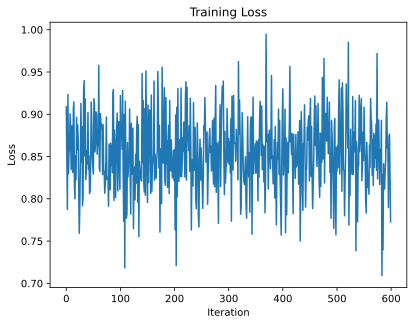

In [ ]:
#训练网络
epochs=20
losses=[]
for epoch in range(epochs):
    TrainModel.train() #训练模式
    correct=0
    total=0
    for (x,y) in train_loader:#获取小批次x,y
        x,y=x.to(device),y.to(device)

        Pred=TrainModel(x)#一次前向传播
        loss=0.8*loss_fn1(Pred,y)#+0.2*loss_fn2(Pred,y)#计算损失函数
        losses.append(loss.item())
        optimizer.zero_grad()#清理上一轮滞留的梯度
        loss.backward()#一次反向传播
        optimizer.step()#优化内部参数

        correct    += (Pred.argmax(dim=1) == y).sum().item()
        total      += y.size(0)
    scheduler.step()
    train_acc  = correct    / total
    #test_acc   = evaluate(test_loader)

    # 保存最优模型
    #if test_acc > best_acc:
        #best_acc = test_acc
        #torch.save(model.state_dict(), "best_mlp.pth")

    print(f"Epoch [{epoch+1:02d}/{epochs}]  "
          f"Train Acc: {100*train_acc:.4f}%  "
          f"lr: {scheduler.get_last_lr()[0]:.2e}")

# 绘制损失曲线
Fig = plt.figure()
plt.plot(range(len(losses)), losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [17]:
def evaluate(loader):
    """返回在给定 loader 上的准确率"""
    TrainModel.eval()
    correct = total = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = TrainModel(X_batch).argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total   += y_batch.size(0)
    return correct / total

print("正在评估测试集...")#57.2% 20epochs
print(f"测试集准确率：{evaluate(test_loader)*100:.4f}%")

正在评估测试集...
测试集准确率：57.0100%


In [10]:
#TrainModel.state_dict(), "best_mlp.pth"

In [11]:
#torch.save(TrainModel.state_dict(), "best_mlp.pth")

In [12]:
#BestModel=TrainModel()
#BestModel.load_state_dict(torch.load("best_mlp.pth"))